# 04 LILAC SH5 Forward-Dynamics Inference: Vader5 2DoF + Manual Hand

Runs the trained LILAC mapping under the same MuJoCo forward-dynamics control path used by `01_lilac_collect_fd_sh5.ipynb`. The Vader5 left stick provides the 2-DoF latent input, while X/Y manually controls the hand preset outside the LILAC model.

In [1]:
%run ../../../ri_motion_v5_package/init_scripts/init_ipython_setup.py
%run ../../../ri_motion_v5_package/init_scripts/init_qt.py
%run ../package/init_project.py

import numpy as np
import threading

from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.vader5 import *


Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.

[LILAC_project] initialized.
Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.
pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
# Inference tuning. Model/data paths come from package/paths.py.
OBJECT_SITE_NAMES = DEFAULT_TASK_OBJECT_SITE_NAMES
INFERENCE_HZ = 30
VADER5_DEADZONE = 0.15
CONTACT_RUMBLE_ENABLED = True
CONTACT_RUMBLE_LOW = 0.0
CONTACT_RUMBLE_HIGH = 1.0
CONTACT_RUMBLE_DURATION_MS = 120
CONTACT_RUMBLE_ROBOT_BODY_PREFIXES = (
    "base_link",
    "lift_link",
    "arm_base_link",
    "head_link",
    "arm_l_link",
    "arm_r_link",
    "hx5_l_base",
    "hx5_r_base",
    "finger_l_link",
    "finger_r_link",
)
LILAC_ACTION_POS_SCALE = 0.01
LILAC_ACTION_ROT_SCALE = 0.04
RESET_OBJECT_BODY_NAMES = list(DEFAULT_RESET_OBJECT_BODY_NAMES)

# Sim STT trigger. Button 11 starts Whisper-small transcription and queues the result as an utterance.
STT_ENABLED = True
STT_LOAD_ON_START = True
STT_DURATION_SEC = 4.0
STT_SAMPLE_RATE = DEFAULT_STT_SAMPLE_RATE
STT_INPUT_DEVICE = None
STT_LANGUAGE = None

# Paper-faithful LILAC: only Vader5 left stick affects the learned arm action.
# The right hand is not part of the model state/action; X/Y only changes the manual preset grasp.
HAND_PRESET_ENABLED = True
HAND_GRIP_SPEED = 2.0
AUTO_GRASP = False
AUTO_GRASP_DISTANCE = 0.075
AUTO_GRASP_SPEED = 2.0


In [3]:
# Scene
env = MuJoCoParser(rel_xml_path=SCENE_XML, verbose=False)

ctrl_group = group_by_prefix(
    items       = env.ctrl_names,
    prefix_dict = {
        "lift" : "lift",
        "arm"  : ["arm_l", "arm_r"],
        "hand" : ["finger_l", "finger_r"],
    },
)
ctrl_names_fd = ctrl_group["lift"] + ctrl_group["arm"] + ctrl_group["hand"]
env.restore_ctrl_info(ctrl_names=ctrl_names_fd, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["lift"], p_gain=1e6, d_gain=100.0, force=2e5, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["arm"], p_gain=3000.0, d_gain=100.0, force=200.0, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["hand"], p_gain=100.0, d_gain=10.0, force=None, verbose=False)
SIM_NSTEP = max(1, int(round(1.0 / (30.0 * env.dt))))
print("SIM_NSTEP:", SIM_NSTEP)


MuJoCo model loaded from [/Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/notebook/xml/scene_ffw_sh5_lilac.xml].
SIM_NSTEP: 17


In [4]:
# Load the single trained LILAC model. The language stack starts empty; send the first instruction by terminal or STT.
runtime = load_lilac_inference_runtime(
    action_pos_scale = LILAC_ACTION_POS_SCALE,
    action_rot_scale = LILAC_ACTION_ROT_SCALE,
)
controller = runtime.controller
command_source = runtime.command_source
model = runtime.model
model_config = runtime.model_config
language_index = runtime.language_index
language_dataset = runtime.language_dataset
runtime_command_path = runtime.command_path

stt_input_devices = []
try:
    import sounddevice as sd
    devices = sd.query_devices()
    stt_input_devices = [
        (idx, dev["name"], int(dev.get("max_input_channels", 0)))
        for idx, dev in enumerate(devices)
        if int(dev.get("max_input_channels", 0)) > 0
    ]
    print("[STT input] sounddevice OK")
    print("[STT input] default device", sd.default.device)
    print("[STT input] input devices", stt_input_devices)
except Exception as exc:
    print("[STT input] sounddevice error:", repr(exc))

stt = WhisperSmallSTT(
    model_name = WHISPER_SMALL_MODEL,
    device     = "auto",
    language   = STT_LANGUAGE,
    verbose    = True,
)
if STT_ENABLED and STT_LOAD_ON_START:
    print("[STT] loading Whisper model before starting the sim loop...")
    stt.load()
    print("[STT] warm-up ready")

print("[LILAC inference] runtime language input:")
print("  STT: Vader5 button 11 records speech and queues utterance")
print("  Fallback terminal:")
print("  /opt/anaconda3/envs/ri_motion_v5_env/bin/python project/LILAC_project/scripts/runtime_language_cli.py")


[LILAC inference] loaded latent alignment /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/runs/lilac_sh5_right/latent_alignment.npz
[LILAC inference] loaded /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/runs/lilac_sh5_right
state_dim 19 action_dim 6 latent_dim 2
[STT input] sounddevice OK
[STT input] default device [1, 2]
[STT input] input devices [(1, 'MacBook Air 마이크', 1), (3, 'WebexMediaAudioDevice', 2)]
[STT] loading Whisper model before starting the sim loop...


Device set to use mps


[STT] loaded openai/whisper-small
[STT] warm-up ready
[LILAC inference] runtime language input:
  STT: Vader5 button 11 records speech and queues utterance
  Fallback terminal:
  /opt/anaconda3/envs/ri_motion_v5_env/bin/python project/LILAC_project/scripts/runtime_language_cli.py


In [5]:
# Reset environment and initialize viewer
env.reset()
env.init_viewer(
    title     = "LILAC SH5 inference 04 - forward dynamics",
    x_offset  = 0.22,
    width     = 1.0,
    height    = 1.0,
    fontscale = 200,
)
env.viewer.set_cam_info(-54.03, 1.35, -34.22, np.array([ 0.4 , -0.16,  1.12]))
env.viewer.set_transparency(transparent=False)
env.viewer.set_geomgroup(group_2=True, group_3=False)
env.viewer.set_sitegroup(group_0=False)
env.set_p("base_link", "body", (0, 0, 0.01))
env.forward(q=[-0.1], joint_names=["lift_joint"])
env.forward(
    q=[1.12, -0.14, -0.15, -2.48, -0.18, -0.22, -0.02],
    joint_names=[
        "arm_r_joint1", "arm_r_joint2", "arm_r_joint3", "arm_r_joint4",
        "arm_r_joint5", "arm_r_joint6", "arm_r_joint7",
    ],
)
env.forward(
    q=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    joint_names=[
        "arm_l_joint1", "arm_l_joint2", "arm_l_joint3", "arm_l_joint4",
        "arm_l_joint5", "arm_l_joint6", "arm_l_joint7",
    ],
)

reset_object_body_names = [name for name in RESET_OBJECT_BODY_NAMES if name in env.body_names]

def reset_task_objects():
    reset_freejoint_bodies_to_xml_pose(env, reset_object_body_names)

reset_task_objects()
object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)
vader5 = build_vader5_handler(joystick_idx=0, verbose=True)
js = vader5.js

use_r_joint_names = get_right_arm_joint_names(env)
right_hand_joint_names = get_right_finger_joint_names()
idxs_ctrl_arm = env.get_ctrl_idxs_attached_joints(use_r_joint_names)
idxs_ctrl_hand = env.get_ctrl_idxs_attached_joints(right_hand_joint_names)
ctrl_vals = env.get_ctrl_qpos(ctrl_names=env.ctrl_names)
ik_solver = build_right_arm_ik_solver(env, use_r_joint_names=use_r_joint_names)
T_rpalm_init = get_right_palm_T(env).copy()
T_rpalm_trgt = T_rpalm_init.copy()
right_grasp_init = 0.0
right_grasp = right_grasp_init
q_arm_cmd = env.get_qpos(joint_names=use_r_joint_names).copy()
q_hand_cmd = get_right_finger_qpos(right_grasp)
env.forward(q=q_arm_cmd, joint_names=use_r_joint_names)
env.forward(q=q_hand_cmd, joint_names=right_hand_joint_names)
ctrl_vals[idxs_ctrl_arm] = q_arm_cmd
ctrl_vals[idxs_ctrl_hand] = q_hand_cmd
env.set_zero_qvel()
state = vader5.get_state(update_first=False)
z_raw = np.zeros(2)
z = np.zeros(2)
lilac_info = {
    "source": "model_fd",
    "utterance": controller.active_utterance(),
    "alpha": 1.0,
    "action": np.zeros(6),
}


name:[Nintendo Switch Pro Controller]
axes:[6]
buttons:[20]
MuJoCo model loaded from [/Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/notebook/xml/scene_ffw_sh5_lilac.xml].


[LILAC FD 2DoF] Initialized with [30.0]HZ. MAX_SEC:[inf]sec.
[Render] Initialized with [30.0]HZ. MAX_SEC:[inf]sec.
[LILAC FD 2DoF] Start ([30.0]HZ. MAX_SEC:[inf]sec).
[Render] Start ([30.0]HZ. MAX_SEC:[inf]sec).
[LILAC FD 2DoF][1] run delayed! T:[33.3]ms run:[50.9]ms]
[Render][1][0.1s] delayed! T:[33.3]ms interval:[52.7]ms prev_run:[0.0]ms.
[Render][1] run delayed! T:[33.3]ms run:[387.2]ms]
[LILAC FD 2DoF][2][0.4s] delayed! T:[33.3]ms interval:[438.8]ms prev_run:[50.9]ms.
[Render][2][0.5s] delayed! T:[33.3]ms interval:[401.2]ms prev_run:[387.2]ms.
[Render][2] run delayed! T:[33.3]ms run:[60.0]ms]
[LILAC FD 2DoF][3][0.5s] delayed! T:[33.3]ms interval:[73.8]ms prev_run:[13.4]ms.
[Render][3][0.5s] delayed! T:[33.3]ms interval:[72.5]ms prev_run:[60.0]ms.
[Render][3] run delayed! T:[33.3]ms run:[43.4]ms]
[LILAC FD 2DoF][4][0.6s] delayed! T:[33.3]ms interval:[55.5]ms prev_run:[12.0]ms.
[Render][4][0.6s] delayed! T:[33.3]ms interval:[54.2]ms prev_run:[43.4]ms.
[Render][4] run delayed! T:[33.3

`return_token_timestamps` is deprecated for WhisperFeatureExtractor and will be removed in Transformers v5. Use `return_attention_mask` instead, as the number of frames can be inferred from it.


[STT] transcribing
[Render][184] run delayed! T:[33.3]ms run:[45.6]ms]
[LILAC FD 2DoF][185][10.9s] delayed! T:[33.3]ms interval:[55.2]ms prev_run:[9.5]ms.
[Render][185][10.9s] delayed! T:[33.3]ms interval:[61.3]ms prev_run:[45.6]ms.
[Render][185] run delayed! T:[33.3]ms run:[50.3]ms]
[LILAC FD 2DoF][186][11.0s] delayed! T:[33.3]ms interval:[66.1]ms prev_run:[15.7]ms.
[Render][186][11.0s] delayed! T:[33.3]ms interval:[61.2]ms prev_run:[50.3]ms.
[Render][186] run delayed! T:[33.3]ms run:[50.1]ms]
[LILAC FD 2DoF][187][11.0s] delayed! T:[33.3]ms interval:[61.1]ms prev_run:[10.8]ms.
[Render][187][11.0s] delayed! T:[33.3]ms interval:[61.2]ms prev_run:[50.1]ms.
[Render][187] run delayed! T:[33.3]ms run:[78.5]ms]
[LILAC FD 2DoF][188][11.1s] delayed! T:[33.3]ms interval:[89.6]ms prev_run:[10.9]ms.
[Render][188][11.1s] delayed! T:[33.3]ms interval:[91.7]ms prev_run:[78.5]ms.
[Render][188] run delayed! T:[33.3]ms run:[48.8]ms]
[LILAC FD 2DoF][189][11.2s] delayed! T:[33.3]ms interval:[61.8]ms prev

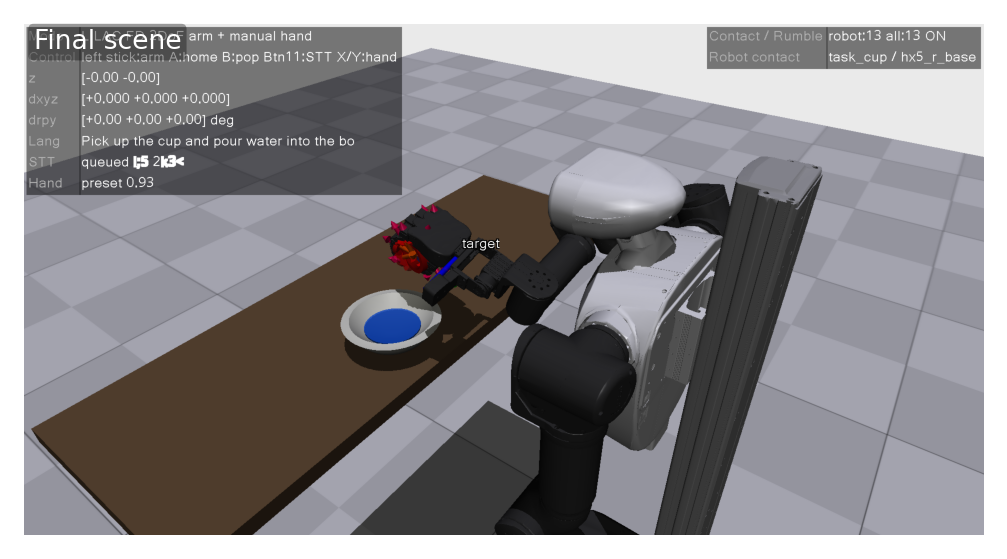

: 

In [ ]:
tmr_control = SimpleTimer(name="LILAC FD 2DoF", Hz=INFERENCE_HZ, verbose=True)
tmr_render = SimpleTimer(name="Render", Hz=30, verbose=True)
tmr_language = SimpleTimer(name="LanguageCommand", Hz=5, verbose=False)
tmr_control.start()
tmr_render.start()
tmr_language.start()
env.reset_wall_time()

prev_button_a = 0
prev_button_b = 0
prev_button_stt_trigger = 0
stt_busy = False
stt_last_text = ""
stt_last_error = ""
stt_last_state = "idle"
contact_info = {"n_contact": 0}
robot_contact_info = {"n_contact": 0}
contact_on = False
vibrate_on = False


def is_robot_contact_body(body_name):
    return str(body_name).startswith(CONTACT_RUMBLE_ROBOT_BODY_PREFIXES)


def filter_robot_asset_contact_info(env, contact_info):
    n_all = int(contact_info.get("n_contact", 0))
    keep_idxs = []
    for c_idx in range(n_all):
        body1_name = env.body_names[int(contact_info["body1_idx_list"][c_idx])]
        body2_name = env.body_names[int(contact_info["body2_idx_list"][c_idx])]
        if is_robot_contact_body(body1_name) or is_robot_contact_body(body2_name):
            keep_idxs.append(c_idx)

    filtered = {}
    for key, value in contact_info.items():
        if key == "n_contact":
            continue
        if isinstance(value, list) and len(value) == n_all:
            filtered[key] = [value[idx] for idx in keep_idxs]
        else:
            filtered[key] = value
    filtered["n_contact"] = len(keep_idxs)
    if keep_idxs:
        filtered["min_contact_dist"] = min(float(contact_info["contact_list"][idx].dist) for idx in keep_idxs)
    else:
        filtered["min_contact_dist"] = np.inf
    return filtered


def summarize_contact_pair(env, contact_info):
    if int(contact_info.get("n_contact", 0)) <= 0:
        return "none"
    body1_name = env.body_names[int(contact_info["body1_idx_list"][0])]
    body2_name = env.body_names[int(contact_info["body2_idx_list"][0])]
    return "%s / %s" % (body1_name, body2_name)


def start_stt_capture():
    global stt_busy, stt_last_text, stt_last_error, stt_last_state
    if not STT_ENABLED:
        print("[STT] disabled")
        return
    if stt_busy:
        print("[STT] already recording/transcribing")
        return

    stt_busy = True
    stt_last_error = ""
    stt_last_text = ""
    stt_last_state = "starting"

    def worker():
        global stt_busy, stt_last_text, stt_last_error, stt_last_state
        try:
            if not stt_input_devices and STT_INPUT_DEVICE is None:
                raise RuntimeError("No microphone input device detected. Check macOS microphone permission for Jupyter/Terminal.")

            stt_last_state = "loading"
            print("[STT] loading model")
            stt.load()

            stt_last_state = "recording"
            print("[STT] recording %.1f sec" % STT_DURATION_SEC)
            audio = stt.record_audio(
                duration_sec = STT_DURATION_SEC,
                sample_rate  = STT_SAMPLE_RATE,
                input_device = STT_INPUT_DEVICE,
            )

            stt_last_state = "transcribing"
            print("[STT] transcribing")
            text, _ = stt.transcribe_audio(audio=audio, sample_rate=STT_SAMPLE_RATE)
            stt_last_text = text
            stt_last_state = "done"
            print("[STT]", repr(text))
            if text:
                append_runtime_language_command(RUNTIME_LANGUAGE_COMMAND, "utterance " + text)
                stt_last_state = "queued"
                print("[language] queued utterance", repr(text))
        except Exception as exc:
            stt_last_error = str(exc)
            stt_last_state = "error"
            print("[STT error]", repr(exc))
        finally:
            stt_busy = False

    threading.Thread(target=worker, daemon=True).start()


try:
    while env.is_viewer_alive():
        env.increase_wall_time()

        if tmr_language.do_run():
            events = command_source.poll(controller)
            for event in events:
                print("[language]", event)
            tmr_language.end()

        if tmr_control.do_run():
            state = vader5.get_state(update_first=True)
            object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)

            button_a = int(js.get_button(VADER5_BUTTON_A))
            button_b = int(js.get_button(VADER5_BUTTON_B))
            button_stt_trigger = int(js.get_button(VADER5_BUTTON_STT_TRIGGER))
            a_pressed = button_a == 1 and prev_button_a == 0
            b_pressed = button_b == 1 and prev_button_b == 0
            stt_trigger_pressed = button_stt_trigger == 1 and prev_button_stt_trigger == 0
            prev_button_a = button_a
            prev_button_b = button_b
            prev_button_stt_trigger = button_stt_trigger

            if a_pressed:
                T_rpalm_trgt = T_rpalm_init.copy()
                right_grasp = right_grasp_init
                q_hand_cmd = get_right_finger_qpos(right_grasp)
                ctrl_vals[idxs_ctrl_hand] = q_hand_cmd
                reset_task_objects()
                object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)
                vader5.reset_motion_memory(rot_dir="yaw")
                print("[home] returned to initial right-palm target, hand preset, and task objects")

            if b_pressed:
                popped = controller.pop_correction()
                active_text = controller.active_utterance() or "<none>"
                print("[language] B pop:", popped, "->", active_text)

            if stt_trigger_pressed:
                start_stt_capture()

            q_arm_curr = env.get_qpos(joint_names=use_r_joint_names)
            ee_pose_curr = T_to_pose6(get_right_palm_T(env))
            state_vec = np.concatenate([q_arm_curr, ee_pose_curr, object_state])

            z_raw = vader5_state_to_latent_z(state, th=VADER5_DEADZONE)
            z = z_raw
            T_rpalm_trgt, lilac_info = controller.safe_update_target(
                T_curr = T_rpalm_trgt,
                state  = state_vec,
                z      = z,
            )
            lilac_info["z_raw"] = z_raw.copy()

            if AUTO_GRASP:
                p_hand = T_to_pose6(T_rpalm_trgt)[:3]
                dist = np.linalg.norm(p_hand - object_state[:3])
                if dist < AUTO_GRASP_DISTANCE:
                    right_grasp = float(
                        np.clip(
                            right_grasp + AUTO_GRASP_SPEED * tmr_control.dt,
                            0.0,
                            1.0,
                        )
                    )

            if HAND_PRESET_ENABLED:
                right_grasp = update_right_finger_command(
                    vader5      = vader5,
                    right_grasp = right_grasp,
                    dt          = tmr_control.dt,
                    grip_speed  = HAND_GRIP_SPEED,
                )

            q_r_best, ik_info = solve_right_palm_ik(
                env               = env,
                ik_solver         = ik_solver,
                T_rpalm_trgt      = T_rpalm_trgt,
                use_r_joint_names = use_r_joint_names,
            )
            q_arm_cmd = q_r_best.copy()
            q_hand_cmd = get_right_finger_qpos(right_grasp)
            ctrl_vals[idxs_ctrl_arm] = q_arm_cmd
            ctrl_vals[idxs_ctrl_hand] = q_hand_cmd

            env.compensate_gravity(root_body_names=["base_link"], on=True)
            env.step(ctrl=ctrl_vals, nstep=SIM_NSTEP)

            contact_info = env.get_contact_info(forward=False)
            robot_contact_info = filter_robot_asset_contact_info(env, contact_info)
            contact_on = int(robot_contact_info["n_contact"]) > 0
            vibrate_on = CONTACT_RUMBLE_ENABLED and contact_on
            if vibrate_on:
                vader5.rumble(CONTACT_RUMBLE_LOW, CONTACT_RUMBLE_HIGH, CONTACT_RUMBLE_DURATION_MS)

            tmr_control.end()

        if tmr_render.do_run():
            active = str(lilac_info.get("utterance", controller.active_utterance()))[:42]
            env.plot_T(T=T_rpalm_trgt, axis_len=0.12, axis_width=0.006, label="target")
            env.viewer_text_overlay("Mode", "LILAC FD 2DoF arm + manual hand", loc="top left")
            env.viewer_text_overlay("Control", "left stick:arm A:home B:pop Btn11:STT X/Y:hand", loc="top left")
            action = np.asarray(lilac_info.get("action", np.zeros(6)), dtype=np.float64)
            env.viewer_text_overlay("z", "[%+.2f %+.2f]" % (z[0], z[1]), loc="top left")
            env.viewer_text_overlay("dxyz", "[%+.3f %+.3f %+.3f]" % (action[0], action[1], action[2]), loc="top left")
            drpy_deg = action[3:] * 180.0 / np.pi
            env.viewer_text_overlay("drpy", "[%+.2f %+.2f %+.2f] deg" % (drpy_deg[0], drpy_deg[1], drpy_deg[2]), loc="top left")
            env.viewer_text_overlay("Lang", active, loc="top left")
            env.viewer_text_overlay("STT", "%s %s" % (stt_last_state, stt_last_text[:28]), loc="top left")
            if stt_last_error:
                env.viewer_text_overlay("STT Error", stt_last_error[:48], loc="top left")
            env.viewer_text_overlay("Hand", "preset %.2f" % right_grasp, loc="top left")
            n_contact_all = int(contact_info.get("n_contact", 0))
            n_contact_robot = int(robot_contact_info.get("n_contact", 0))
            env.viewer_text_overlay(
                "Contact / Rumble",
                "robot:%d all:%d %s" % (n_contact_robot, n_contact_all, "ON" if vibrate_on else "OFF"),
                loc="top right",
            )
            if contact_on:
                env.viewer_text_overlay("Robot contact", summarize_contact_pair(env, robot_contact_info)[:48], loc="top right")
                env.plot_contact_info(robot_contact_info)
            env.render()
            tmr_render.end()
except KeyboardInterrupt:
    print("Interrupted.")
finally:
    env.close_viewer()
    vader5.close()
    imshow(env.final_rgb_img, title="Final scene", title_fs=8)
